---
tags: [algorithm, finance, simulation]
---

# 量子コンピュータによるリスク分析

Value at Risk (VaR) や Conditional Value at Risk (CVaR) の計算は、金融リスクを定量化する上でとても重要です。
この計算には古典モンテカルロシミュレーション手法が用いられてきましたが、計算量が膨大なものとなる問題がありました。
その計算量を緩和し、より高速な計算を可能にする技術として、量子コンピュータによる手法が考案されています。
そこで本記事では、VaR および CVaR を量子コンピュータ乗で効率的に計算するアルゴリズムを提案した [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) を題材に、Qamomileによる実装の一例をまとめました。

In [2]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qamomile.circuit as qmc
from qamomile.circuit.stdlib import iqft, ripple_carry_add
from qamomile.qiskit import QiskitTranspiler
from scipy.stats import norm

## 背景

### 問題: VaR と CVaR の計算

リスク管理は、金融システムにおいて中心的な役割を担っています。
中でも VaR は「ある期間の間にある確率以内に収まる最大損失額はいくらか」を表し、そして CVaR は「VaRを下回る資産価値の期待値はいくらか」を示す、非常に重要な指標となっています。  
古典モンテカルロシミュレーションは、VaR と CVaR を求める標準的な手法です。
しかしサンプル数 $M$ に対し、その誤差は $\mathcal{O}(M^{-1/2})$ でスケールすることが知られており、その減衰の遅さがボトルネックとなっています。
その性能を改善したものとして、分散減少法 (variance reduction) や 準モンテカルロ法 (Quasi-Monte Carlo: QMC) などがあります。
前者は漸近的なスケーリングを変えずに定数を削減しますが、問題に応じた構造設計が必要で、汎用性に欠けます。
また後者は漸近的な振る舞いを改善しますが、その有効性は低次元に限られており、現実問題への適用には適していません。  
量子振幅推定 (QAE) は未知のパラメータを推定するための量子アルゴリズムであり、$\mathcal{O}(M^{-1})$ で収束することが知られています。
これはモンテカルロのような古典手法に対し、2次的な量子高速化を実現します。
そこで [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) では、QAE を確率分布の分散・VaR・CVaR の計算へと拡張する手法を提案しました。
また浅い回路の場合についても議論することで、その NISQ 実装についても焦点を当てました。

### 先行研究

QAEによりモンテカルロ計算を高速化できることを示した重要な研究に、[Montanaro (2015)](https://royalsocietypublishing.org/rspa/article/471/2181/20150301/57575/Quantum-speedup-of-Monte-Carlo-methodsQuantum) があります。
この研究では一般的な設定において、QAE がモンテカルロ法を高速化できることを理論的に示しました。
さらに量子ウォークと組合せることで、多段マルコフ連鎖モンテカルロ法による分配関数計算の古典手法を高速化できることも示しました。
そして金融デリバティブのモンテカルロプライシングのための量子アルゴリズムを提案した先行研究として、[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321) があります。
この論文では QAE を用いることで、プライシング推定値を得るために必要なステップ数において、2次的な量子高速化を達成できるという理論・数値シミュレーションを示しました。
しかし [Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321) では期待値の計算にとどまっており、QAE を直接当てはめやすい問題設定 (より具体的にはデリバティブの公正価値の計算) のみに着目した計算を行なっていました。
VaR や CVaR を計算する問題は基本的に非線形であり、QAE をそのまま当てはめることはできません。
そこで [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) は QAE を、VaR と CVaR の計算という、より実務に即した指標計算に拡張しました。

## アルゴリズム

### 確率分布の量子状態符号化

最初に、確率変数 $X$ の分布を量子状態として表現しましょう。
$n$ 量子ビットを用い、確率変数の値域を $\{0, 1, \dots, N-1\} \ (N=2^n)$ で離散化します。
確率変数 $X$ を次のような量子状態で表すような、演算子 $\mathcal{R}$ を準備します。

$$
\mathcal{R} \vert 0 \rangle_n 
= \vert \psi \rangle_n
= \sum_{i=0}^{N-1} \sqrt{p_i} \vert i \rangle_n \tag{1}
$$

ここで $p_i$ は $\vert i \rangle_n$ が測定される確率であり、$\sum_i p_i = 1$ です。

### 目標演算子 $F$

次に、$f(i) \in [0, 1]$ のような関数と、これがアンシラ量子ビットの状態の係数として現れることを実現するような演算子を $F$ としましょう。

$$
F \vert i \rangle_n \vert 0 \rangle 
= \vert i \rangle_n \left( \sqrt{1-f(i)} \vert 0 \rangle + \sqrt{f(i)} \vert 1 \rangle \right) \tag{2}
$$

このような演算子 $F$ を式(1)に作用させることで

$$
F \vert \psi \rangle_n \vert 0 \rangle 
= \sum_{i=0}^{N-1} \sqrt{1-f(i)} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i=0}^{N-1} \sqrt{f(i)} \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle \tag{3}
$$

を得ます。
この状態において、アンシラ量子ビットが $\vert 1 \rangle$ となる確率を測定すると

$$
P_1 
= \sum_{i=0}^{N-1} f(i) p_i \tag{4}
$$

のようになります。
式(4)は関数 $f(i)$ の期待値 $\mathbb{E}[f(X)]$ に対応しますが、関数 $f(X)$ の形により求められる統計量が変化します。
次表は、求めたい統計量と関数 $f(i)$ の対応を示したものです。

|統計量|$f(i)$|
|-|-|
|$\mathbb{E}[X]$|$i/(N-1)$|
|$\mathbb{E}[X^2]$|$i^2/(N-1)^2$|

[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) では QAE を用いることで、$\vert 1 \rangle$ の前の係数 $P_1$ を推定します。  
$f(i)$ を直接 $F$ として量子回路に実装するには、多くの補助量子ビットを必要とします。
そこで [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) では次のような近似を行いました。
次数 $k$ の多項式 $\zeta(x)$ を用い、次のような演算を行う演算子を考えましょう。

$$
\vert x \rangle_n \vert 0 \rangle \longrightarrow
\vert x \rangle_n (\cos \zeta(x) \vert 0 \rangle + \sin \zeta(x) \vert 1 \rangle) \tag{5}
$$

これは多制御Y回転であり、$\mathcal{O}(n^{k+1})$ ゲートと $\mathcal{O}(n)$のアンシラで実装が可能です。
この演算後に補助量子ビットが $\vert 1 \rangle$ となる確率は $\sin^2 \zeta(x)$ となります。  
$\vert y \vert$ が小さいとき $\sin^2(y + \pi/4) \approx y + 1/2$ が成り立つことを利用し、$y = f(i) \in [0,1]$ とおくと

$$
c\!\left(y - \frac{1}{2}\right) + \frac{1}{2}
\approx \sin^2\!\left(c\,\zeta(y) + \frac{\pi}{4}\right)
\implies
\zeta(y) \approx \frac{1}{c}\!\left\{\arcsin\sqrt{c\!\left(y-\frac{1}{2}\right)
+\frac{1}{2}} - \frac{\pi}{4}\right\} \tag{6}
$$

のように変形できます。
これをさらに $y = 1/2$ の周りでテイラー展開 (次数 $2u+1$) して用いることにします。
$\zeta(y)$ は $y=1/2$ に対して奇関数であるため、偶数次の項がゼロとなり効率的に実装できます。
この近似の下で QAE を実行したときの全体誤差は

$$
\varepsilon = \mathcal{O}\!\left(M^{-\frac{2u+2}{2u+3}}\right) \tag{7}
$$

のように与えられます。
$u=0$（最小回路深さ）でも $\mathcal{O}(M^{-2/3})$ となり、古典モンテカルロ $\mathcal{O}(M^{-1/2})$ を凌駕する収束性を持ちます。
$u$ を増やすことで、最適な $\mathcal{O}(M^{-1})$ に漸近することがわかります。

### VaR と CVaR の計算

ここまでの計算を、VaR と CVaR に拡張しましょう。
与えられた信頼度 $\alpha \in [0, 1]$ に対し、$\mathrm{VaR}_\alpha (X)$ は $P[X \leq x] \geq 1-\alpha$ を満たす最小の $x \in \{0, 1, \dots, N-1\}$、すなわち損失分布の $1-\alpha$ 分位点です。
これを計算するには、$f_\ell (i) = \mathbf{1}(i \leq \ell)$ が考えられます。
ここで $\mathbf{1}(i \leq \ell)$ は、$i \leq \ell$ ならば1、そうでないなら0を返す二値関数で、指示関数と呼ばれます。
実際に、この $f_\ell (i)$ に対応する $F_\ell$ を $\vert \psi \rangle_n \vert 0 \rangle$ に作用させると

$$
F_\ell \vert \psi \rangle_n \vert 0 \rangle 
= \sum_{i=0}^{N-1} \sqrt{1-f_\ell(i)} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i=0}^{N-1} \sqrt{f_\ell(i)} \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle 
= \sum_{i=\ell+1}^{N-1} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i=0}^\ell \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle \tag{8}
$$

のようになり、アンシラ量子ビットにおける $\vert 1 \rangle$ の測定確率が $\sum_{i=0}^\ell p_i = P[X \leq \ell]$ のようになります。
先ほど説明したように、QAEを用いて $a_\ell = \mathbf{E}[f_\ell (X)] = P[X \leq \ell]$ を推定し、これを求めます。  
$\ell$ に関しては、二分探索を行えば良いでしょう。
二分探索を行うことで、$P[X \leq \ell_\alpha] \geq 1-\alpha$ を満たす最小の信頼度 $\ell_\alpha$ を、最大 $\mathcal{O}(\log 2^n) = \mathcal{O}(n)$ ステップで見つけることができます。  
続いて、CVaR の計算方法を見てみましょう。
VaR の計算から、 $\ell_\alpha = \mathrm{VaR}_\alpha (X)$ がすでに求まっているとします。
これを用いると、CVaR は次のように書くことができます。

$$
\mathrm{CVaR}_\alpha (X) 
= \mathbb{E} [X \vert X \leq \ell_\alpha] 
= \frac{\mathbb{E}[X \cdot \mathbf{1} [X \leq \ell_\alpha]]}{P[X \leq \ell_\alpha]} \tag{9}
$$

この式の分母の部分は VaR の計算に付随して得ることができます。
次に、分子について整理すると

$$
\mathbb{E} [X \cdot \mathbf{1} [X \leq \ell_\alpha]] 
= \sum_{i=0}^{N-1} i \mathbf{1} [i \leq \ell_\alpha] p_i 
= \sum_{i=0}^{\ell_\alpha} i p_i \tag{10}
$$

のようになります。
先ほど述べたように、関数 $f$ の期待値 $\mathbb{E} [f(X)]$ は QAE を用いて推定することができます。
しかし、QAE で推定できるのは $[0, 1]$ の範囲にある量 (すなわち確率) のみです。
式(10)は一般に $[0, 1]$ を超えるため、$0 \leq i \leq \ell_\alpha$ を $\ell_\alpha$ で割ることにしましょう。

$$
\mathbb{E} \left[ \frac{X}{\ell_\alpha} \cdot \mathbf{1} [X \leq \ell_\alpha] \right] 
= \sum_{i=0}^{\ell_\alpha} \frac{i}{\ell_\alpha} p_i \in [0, 1] \tag{11}
$$

式(4)と式(11)を見比べると、関数 $f(i)$ は

$$
f(i) 
= \frac{i}{\ell_\alpha} \mathbf{1} [i \leq \ell_\alpha] \tag{12}
$$

のようになります。
QAE でこの $\mathbb{E} [f(X)]$ を推定し、その後で $\ell_\alpha$ をかけることで、CVaRを求めることができます。

## Qamomileによる実装

それでは [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) で提案された手法を、Qamomile で実装しましょう。

### 古典コンピュータによる処理

確率分布として、正規分布を $N = 2^n$ 点で離散化し、振幅符号化に必要な $\sqrt{p_i}$ を準備しましょう。
また、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) での最小 depth の場合、$u=0$ では $\zeta(y) \simeq y - \frac{1}{2}$ となります。
主要項だけ見ると、推定誤差はおよそ 

$$
\epsilon (c) 
\simeq \frac{\pi}{Mc} + \frac{c^2}{6} \tag{13}
$$

です。
これを最小化する $c \simeq \left( \frac{3\pi}{M}\right)^{1/3}$ を利用し、$c \leq 1$ に制限します。

In [4]:
# ===================================================
# Step 0: 古典的な前処理
# ===================================================

def make_normal_amplitudes(n: int, mu: float = 0.0, sigma: float = 1.0) -> np.ndarray:
    N = 2 ** n
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, N)
    probs = norm.pdf(x, mu, sigma)
    probs /= probs.sum()
    return np.sqrt(probs)


def choose_u0_scaling_c(m: int) -> float:
    """Woerner--Egger の u=0 近似で用いる scaling c を選ぶ。"""
    M = 2 ** m
    return float(min(1.0, (3.0 * np.pi / M) ** (1.0 / 3.0)))

### カーネルの合成

QAE の Grover 演算子 $Q$ を繰り返し適用するため、Qamomile カーネルを順に合成する補助関数を定義しましょう。
今回の $A$ は、分布レジスタ `q` に加えて comparator の定数レジスタ `const`、ripple-carry 用の `carry` と `overflow`、CVaR の条件判定を保持する `flag`、そして QAE が「good state」を判定する `anc` を受け取ります。すべての workspace は objective の最後に $\lvert0\rangle$ へ戻すため、$A^\dagger$ も Qamomile の `qmc.inverse` で構成できます。

In [5]:
# ===================================================
# Step 1: カーネル合成ユーティリティ
# ===================================================

def merge_system_kernels(left, right):
    @qmc.qkernel
    def merged(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        q, const, carry, overflow, flag, anc = left(
            q, const, carry, overflow, flag, anc
        )
        q, const, carry, overflow, flag, anc = right(
            q, const, carry, overflow, flag, anc
        )
        return q, const, carry, overflow, flag, anc

    return merged


@qmc.qkernel
def _identity_const(
    const: qmc.Vector[qmc.Qubit],
) -> qmc.Vector[qmc.Qubit]:
    return const


def make_const_x_kernel(bit: int):
    @qmc.qkernel
    def x_const(
        const: qmc.Vector[qmc.Qubit],
    ) -> qmc.Vector[qmc.Qubit]:
        const[bit] = qmc.x(const[bit])
        return const

    return x_const


def merge_const_kernels(left, right):
    @qmc.qkernel
    def merged_const(
        const: qmc.Vector[qmc.Qubit],
    ) -> qmc.Vector[qmc.Qubit]:
        const = left(const)
        const = right(const)
        return const

    return merged_const


def make_prepare_constant_kernel(n: int, value: int):
    """|0...0> -> |value> を X ゲートだけで構成する。little-endian。"""
    one_bits = [bit for bit in range(n) if (value >> bit) & 1]
    if not one_bits:
        return _identity_const

    kernel = make_const_x_kernel(one_bits[0])
    for bit in one_bits[1:]:
        kernel = merge_const_kernels(kernel, make_const_x_kernel(bit))
    return kernel


### 目標演算子 $F$ の実装

Qamomile の `ripple_carry_add` を用い、$i \leq \ell$ を判定する comparator を構成します。
VaR ではこの比較結果をそのままアンシラ量子ビットに記録し、$P[X \leq \ell]$ を QAE で推定できるようにします。
CVaR では比較結果を `flag` として利用し、テイル領域にのみ、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) の $u = 0$ のテイラー展開近似による制御 $R_y$ 回転を適用します。

In [6]:
# ===================================================
# Step 2: ripple-carry comparator と Woerner--Egger 型 efficient F
# ===================================================

def make_comparator_arithmetic(n: int, l: int):
    """comparator で使う定数準備・加算・逆加算をまとめて作る。"""
    offset = 2 ** n - 1 - l
    prepare_const = make_prepare_constant_kernel(n, offset)

    @qmc.qkernel
    def add_offset(
        const: qmc.Vector[qmc.Qubit],
        q: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
    ]:
        const, q, carry, overflow = ripple_carry_add(
            const, q, carry, overflow
        )
        return const, q, carry, overflow

    add_offset_dag = qmc.inverse(add_offset)
    return prepare_const, add_offset, add_offset_dag


def make_var_objective_kernel(n: int, l: int):
    """anc ^= 1[q <= l]。すべての workspace は最後に |0> へ戻す。"""
    prepare_const, add_offset, add_offset_dag = make_comparator_arithmetic(n, l)

    @qmc.qkernel
    def objective(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        const = prepare_const(const)
        const, q, carry, overflow = add_offset(
            const, q, carry, overflow
        )

        # overflow = 0 <=> q <= l
        anc = qmc.x(anc)
        overflow, anc = qmc.cx(overflow, anc)

        # arithmetic workspace を uncompute
        const, q, carry, overflow = add_offset_dag(
            const, q, carry, overflow
        )
        const = prepare_const(const)
        return q, const, carry, overflow, flag, anc

    return objective


def make_leq_flag_kernel(n: int, l: int):
    """flag ^= 1[q <= l]。すべての arithmetic workspace は元に戻す。"""
    prepare_const, add_offset, add_offset_dag = make_comparator_arithmetic(n, l)

    @qmc.qkernel
    def comparator(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        const = prepare_const(const)
        const, q, carry, overflow = add_offset(
            const, q, carry, overflow
        )

        flag = qmc.x(flag)
        overflow, flag = qmc.cx(overflow, flag)

        const, q, carry, overflow = add_offset_dag(
            const, q, carry, overflow
        )
        const = prepare_const(const)
        return q, const, carry, overflow, flag, anc

    return comparator


def make_cvar_objective_kernel(n: int, l_alpha: int, c: float):
    """Woerner--Egger の u=0 Taylor 近似を用いた CVaR objective。"""
    if l_alpha <= 0:
        raise ValueError("l_alpha must be positive for the CVaR objective kernel")

    comparator = make_leq_flag_kernel(n, l_alpha)
    cry = qmc.control(qmc.ry)
    ccry = qmc.control(qmc.ry, num_controls=2)

    base_angle = float(np.pi / 2.0 - c)
    bit_angles = [float(2.0 * c * (2 ** bit) / l_alpha) for bit in range(n)]

    @qmc.qkernel
    def base_rotation(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        flag, anc = cry(flag, anc, angle=base_angle)
        return q, const, carry, overflow, flag, anc

    def make_bit_rotation(bit: int, angle: float):
        @qmc.qkernel
        def bit_rotation(
            q: qmc.Vector[qmc.Qubit],
            const: qmc.Vector[qmc.Qubit],
            carry: qmc.Qubit,
            overflow: qmc.Qubit,
            flag: qmc.Qubit,
            anc: qmc.Qubit,
        ) -> tuple[
            qmc.Vector[qmc.Qubit],
            qmc.Vector[qmc.Qubit],
            qmc.Qubit,
            qmc.Qubit,
            qmc.Qubit,
            qmc.Qubit,
        ]:
            flag, q[bit], anc = ccry(flag, q[bit], anc, angle=angle)
            return q, const, carry, overflow, flag, anc

        return bit_rotation

    rotation_kernel = base_rotation
    for bit, angle in enumerate(bit_angles):
        rotation_kernel = merge_system_kernels(
            rotation_kernel,
            make_bit_rotation(bit, angle),
        )

    @qmc.qkernel
    def objective(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        # flag = 1[q <= l_alpha]
        q, const, carry, overflow, flag, anc = comparator(
            q, const, carry, overflow, flag, anc
        )

        # tail 領域だけ efficient F を作用
        q, const, carry, overflow, flag, anc = rotation_kernel(
            q, const, carry, overflow, flag, anc
        )

        # flag を |0> に戻す
        q, const, carry, overflow, flag, anc = comparator(
            q, const, carry, overflow, flag, anc
        )
        return q, const, carry, overflow, flag, anc

    return objective


### 量子振幅推定の実装

先ほど作成した VaR / CVaR のための $F$ を用いて、実際に QAE を構築しましょう。
確率分布の振幅符号化と $F$ を組み合わせて、状態準備演算子 $\mathcal{A}$ を構成し、そこから QAE のための Grover 演算子 $\mathcal{Q} = \mathcal{A} S_0 \mathcal{A}^\dagger S_\chi$ を作ります。

In [7]:
# ===================================================
# Step 3: Fully QAE
# ===================================================

def make_a_kernel(n: int, amplitudes: np.ndarray, objective_kernel):
    """A = F · R カーネル"""

    @qmc.qkernel
    def a_kernel(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        q = qmc.amplitude_encoding(q, amplitudes)
        q, const, carry, overflow, flag, anc = objective_kernel(
            q, const, carry, overflow, flag, anc
        )
        return q, const, carry, overflow, flag, anc

    return a_kernel


def make_grover_q_kernel(n: int, a_ker, a_dag):
    """Grover 反射演算子 Q = A · S0 · A† · Schi"""

    @qmc.qkernel
    def s_chi(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        anc = qmc.x(anc)
        anc = qmc.z(anc)
        anc = qmc.x(anc)
        return q, const, carry, overflow, flag, anc

    # controls = q(n) + const(n) + carry + overflow + flag = 2n+3
    mcz_all = qmc.control(qmc.z, num_controls=2 * n + 3)

    @qmc.qkernel
    def s_0(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        q = qmc.x(q)
        const = qmc.x(const)
        carry = qmc.x(carry)
        overflow = qmc.x(overflow)
        flag = qmc.x(flag)
        anc = qmc.x(anc)

        q, const, carry, overflow, flag, anc = mcz_all(
            q, const, carry, overflow, flag, anc
        )

        q = qmc.x(q)
        const = qmc.x(const)
        carry = qmc.x(carry)
        overflow = qmc.x(overflow)
        flag = qmc.x(flag)
        anc = qmc.x(anc)
        return q, const, carry, overflow, flag, anc

    @qmc.qkernel
    def q_kernel(
        q: qmc.Vector[qmc.Qubit],
        const: qmc.Vector[qmc.Qubit],
        carry: qmc.Qubit,
        overflow: qmc.Qubit,
        flag: qmc.Qubit,
        anc: qmc.Qubit,
    ) -> tuple[
        qmc.Vector[qmc.Qubit],
        qmc.Vector[qmc.Qubit],
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
        qmc.Qubit,
    ]:
        q, const, carry, overflow, flag, anc = s_chi(
            q, const, carry, overflow, flag, anc
        )
        q, const, carry, overflow, flag, anc = a_dag(
            q, const, carry, overflow, flag, anc
        )
        q, const, carry, overflow, flag, anc = s_0(
            q, const, carry, overflow, flag, anc
        )
        q, const, carry, overflow, flag, anc = a_ker(
            q, const, carry, overflow, flag, anc
        )
        return q, const, carry, overflow, flag, anc

    return q_kernel


def make_q_power_kernel(q_kernel, power: int):
    if power == 1:
        return q_kernel

    result = q_kernel
    for _ in range(power - 1):
        result = merge_system_kernels(result, q_kernel)
    return result


def make_qae_kernel(
    n: int,
    m: int,
    amplitudes: np.ndarray,
    objective_kernel,
):
    a_ker = make_a_kernel(n, amplitudes, objective_kernel)
    a_dag = qmc.inverse(a_ker)
    q_ker = make_grover_q_kernel(n, a_ker, a_dag)

    def merge_qpe_steps(left, right):
        @qmc.qkernel
        def merged_step(
            sv: qmc.Vector[qmc.Qubit],
            q: qmc.Vector[qmc.Qubit],
            const: qmc.Vector[qmc.Qubit],
            carry: qmc.Qubit,
            overflow: qmc.Qubit,
            flag: qmc.Qubit,
            anc: qmc.Qubit,
        ) -> tuple[
            qmc.Vector[qmc.Qubit],
            qmc.Vector[qmc.Qubit],
            qmc.Vector[qmc.Qubit],
            qmc.Qubit,
            qmc.Qubit,
            qmc.Qubit,
            qmc.Qubit,
        ]:
            sv, q, const, carry, overflow, flag, anc = left(
                sv, q, const, carry, overflow, flag, anc
            )
            sv, q, const, carry, overflow, flag, anc = right(
                sv, q, const, carry, overflow, flag, anc
            )
            return sv, q, const, carry, overflow, flag, anc

        return merged_step

    def build_qpe_kernel(step_list: list):
        steps = list(step_list)
        while len(steps) > 1:
            next_steps = []
            for i in range(0, len(steps), 2):
                if i + 1 < len(steps):
                    next_steps.append(merge_qpe_steps(steps[i], steps[i + 1]))
                else:
                    next_steps.append(steps[i])
            steps = next_steps
        return steps[0]

    def make_qpe_step(k: int):
        cqk = qmc.control(make_q_power_kernel(q_ker, 2 ** k))
        sk = k

        @qmc.qkernel
        def qpe_step(
            sv: qmc.Vector[qmc.Qubit],
            q: qmc.Vector[qmc.Qubit],
            const: qmc.Vector[qmc.Qubit],
            carry: qmc.Qubit,
            overflow: qmc.Qubit,
            flag: qmc.Qubit,
            anc: qmc.Qubit,
        ) -> tuple[
            qmc.Vector[qmc.Qubit],
            qmc.Vector[qmc.Qubit],
            qmc.Vector[qmc.Qubit],
            qmc.Qubit,
            qmc.Qubit,
            qmc.Qubit,
            qmc.Qubit,
        ]:
            sv[sk] = qmc.h(sv[sk])
            sv[sk], q, const, carry, overflow, flag, anc = cqk(
                sv[sk], q, const, carry, overflow, flag, anc
            )
            return sv, q, const, carry, overflow, flag, anc

        return qpe_step

    step_kernels = [make_qpe_step(k) for k in range(m)]
    qpe_kernel = build_qpe_kernel(step_kernels)

    @qmc.qkernel
    def qae_kernel() -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n, name="q")
        const = qmc.qubit_array(n, name="const")
        carry = qmc.qubit(name="carry")
        overflow = qmc.qubit(name="overflow")
        flag = qmc.qubit(name="flag")
        anc = qmc.qubit(name="anc")
        sv = qmc.qubit_array(m, name="sv")

        q, const, carry, overflow, flag, anc = a_ker(
            q, const, carry, overflow, flag, anc
        )
        sv, q, const, carry, overflow, flag, anc = qpe_kernel(
            sv, q, const, carry, overflow, flag, anc
        )
        sv = iqft(sv)
        return qmc.measure(sv)

    return qae_kernel


def estimate_amplitude_qae(
    n: int,
    m: int,
    amplitudes: np.ndarray,
    objective_kernel,
    shots: int = 4096,
) -> float:
    M = 2 ** m
    transpiler = QiskitTranspiler()
    kernel = make_qae_kernel(n, m, amplitudes, objective_kernel)
    exe = transpiler.transpile(kernel)
    result = exe.sample(transpiler.executor(), shots=shots).result()

    counts: dict[int, int] = {}
    for outcome, count in result.results:
        if isinstance(outcome, (int, np.integer)):
            y = int(outcome)
        elif isinstance(outcome, tuple):
            flat = []
            for b in outcome:
                if isinstance(b, tuple):
                    flat.extend(int(x) for x in b)
                else:
                    flat.append(int(b))
            y = sum(bit * (2 ** k) for k, bit in enumerate(flat))
        else:
            y = int(outcome)
        counts[y] = counts.get(y, 0) + count

    y_star = max(counts, key=counts.get)
    if y_star > M // 2:
        y_star = M - y_star

    return float(np.sin(y_star * np.pi / M) ** 2)


### VaRとCVaRの計算

QAEによる $P[X \leq \ell]$ の推定と、二部探索を組合せることで、$\mathrm{VaR}_\alpha$ を求めましょう。
各ステップで中間点 $\ell_\mathrm{mid}$ の累積確率を QAE で推定し、$1-\alpha$ との大小比較から探索範囲を縮小していきます。
CVaR 計算では、その VaR 以下の領域に $u = 0$ の $F$ を適用し、 さらに QAE を用います。

In [8]:
# ===================================================
# Step 4: VaR の計算
# ===================================================

def compute_var(
    alpha: float,
    n: int,
    m: int,
    amplitudes: np.ndarray,
    mu: float,
    sigma: float,
    shots: int = 4096,
) -> tuple[int, float, float]:
    """alpha を信頼水準として、下側 (1-alpha) 分位点を QAE で求める。"""
    N = 2 ** n
    tail_prob = 1.0 - alpha
    x_vals = np.linspace(mu - 3 * sigma, mu + 3 * sigma, N)

    l_low, l_high = 0, N - 1
    step = 0

    print(
        f"  VaR 計算開始（confidence={alpha:.1%}, tail={tail_prob:.1%}, "
        f"n={n}, m={m}, N={N}, M={2**m}）"
    )

    while l_low < l_high:
        step += 1
        l_mid = (l_low + l_high) // 2
        objective = make_var_objective_kernel(n, l_mid)
        prob = estimate_amplitude_qae(
            n, m, amplitudes, objective, shots=shots
        )

        print(
            f"    Step {step}: l_mid={l_mid} (x={x_vals[l_mid]:.3f}), "
            f"P[X<=l_mid]~{prob:.4f}"
        )

        if prob >= tail_prob:
            l_high = l_mid
        else:
            l_low = l_mid + 1

    var_alpha_index = l_low
    var_alpha_x = x_vals[var_alpha_index]

    objective = make_var_objective_kernel(n, var_alpha_index)
    prob_var = estimate_amplitude_qae(
        n, m, amplitudes, objective, shots=shots
    )

    print(
        f"  -> VaR_{alpha:.0%} = index {var_alpha_index} "
        f"(x={var_alpha_x:.4f}), P[X<=VaR]~{prob_var:.4f}"
    )
    return var_alpha_index, var_alpha_x, prob_var


# ===================================================
# Step 5: CVaR の計算
# ===================================================

def compute_cvar(
    alpha: float,
    var_alpha_index: int,
    var_alpha_x: float,
    prob_var: float,
    n: int,
    m: int,
    amplitudes: np.ndarray,
    mu: float,
    sigma: float,
    shots: int = 4096,
) -> float:
    """Woerner--Egger の u=0 efficient F を用いて下側 CVaR を推定する。"""
    del alpha, var_alpha_x  # 定義を明示するため引数として残す

    N = 2 ** n
    x_vals = np.linspace(mu - 3 * sigma, mu + 3 * sigma, N)
    x_min = x_vals[0]
    dx = x_vals[1] - x_vals[0]

    if prob_var <= 0.0:
        return float("nan")

    # l_alpha = 0 の場合、選択領域の index は 0 のみ。
    if var_alpha_index == 0:
        return float(x_min)

    c = choose_u0_scaling_c(m)
    objective = make_cvar_objective_kernel(n, var_alpha_index, c)
    amplitude = estimate_amplitude_qae(
        n, m, amplitudes, objective, shots=shots
    )

    # u=0:
    # amplitude ~= c * E[(i/l) 1[i<=l]] + (1-c)/2 * P[i<=l]
    truncated_normalized_mean = (
        amplitude - 0.5 * (1.0 - c) * prob_var
    ) / c

    conditional_mean_index = (
        var_alpha_index * truncated_normalized_mean / prob_var
    )
    cvar_x = x_min + dx * conditional_mean_index

    print(
        f"  CVaR efficient F: c={c:.4f}, QAE amplitude~{amplitude:.4f}, "
        f"E[index | tail]~{conditional_mean_index:.4f}"
    )
    return float(cvar_x)


### 可視化部分の実装

結果をわかりやすく見るために、読み込んだ分布と VaR・CVaR を描画するグラフのための関数を実装しましょう。

In [11]:
# ===================================================
# Step 6: 可視化（m を変化させた場合の精度比較）
# ===================================================

def plot_results_vs_m(
    results_by_m: dict,
    n: int,
    alpha: float,
    mu: float,
    sigma: float,
):
    m_list = sorted(results_by_m.keys())
    N = 2 ** n
    tail_prob = 1.0 - alpha

    x_vals = np.linspace(mu - 3 * sigma, mu + 3 * sigma, N)
    probs = norm.pdf(x_vals, mu, sigma)
    probs /= probs.sum()

    z = norm.ppf(tail_prob)
    theory_var = norm.ppf(tail_prob, mu, sigma)
    theory_cvar = mu - sigma * norm.pdf(z) / tail_prob

    def classical_cvar(var_idx):
        prob_var_true = sum(probs[i] for i in range(var_idx + 1))
        if prob_var_true == 0:
            return 0.0
        return (
            sum(x_vals[i] * probs[i] for i in range(var_idx + 1))
            / prob_var_true
        )

    n_cols = len(m_list)
    fig = plt.figure(figsize=(4 * n_cols, 10))
    gs = plt.GridSpec(
        2,
        n_cols,
        hspace=0.5,
        wspace=0.35,
        height_ratios=[2, 1],
    )

    var_estimates = []
    cvar_estimates = []
    cvar_classical = []

    for col, m in enumerate(m_list):
        ax = fig.add_subplot(gs[0, col])
        res = results_by_m[m]

        var_idx = res["var_alpha_index"]
        var_x = res["var_alpha_x"]
        cvar_val = res["cvar_alpha"]
        cvar_cl = classical_cvar(var_idx)

        var_estimates.append(var_x)
        cvar_estimates.append(cvar_val)
        cvar_classical.append(cvar_cl)

        bar_width = (x_vals[1] - x_vals[0]) * 0.85
        ax.bar(
            x_vals[: var_idx + 1],
            probs[: var_idx + 1],
            width=bar_width,
            color="#D85A30",
            alpha=0.6,
            label="CVaR region",
        )
        ax.bar(
            x_vals[var_idx + 1 :],
            probs[var_idx + 1 :],
            width=bar_width,
            color="#1f77b4",
            alpha=0.6,
        )
        ax.axvline(
            x=var_x,
            color="#D85A30",
            linestyle="--",
            linewidth=1.8,
            label=f"VaR = {var_x:.2f}",
        )
        ax.axvline(
            x=cvar_val,
            color="#7F77DD",
            linestyle=":",
            linewidth=1.8,
            label=f"CVaR = {cvar_val:.2f}",
        )
        ax.axvline(
            x=theory_var,
            color="gray",
            linestyle="-.",
            linewidth=1.0,
            alpha=0.7,
            label=f"Theoretical VaR = {theory_var:.2f}",
        )

        ax.set_title(f"$m={m}$ ($M={2**m}$)", fontsize=11)
        ax.set_xlabel("Portfolio value $X$", fontsize=9)
        ax.set_ylabel("Probability", fontsize=9)
        ax.legend(fontsize=6, loc="upper left")
        ax.set_xlim(x_vals[0] - 0.2, x_vals[-1] + 0.2)

    plt.suptitle(
        f"Quantum Risk Analysis — Woerner & Egger (2019)\n"
        f"Fully QAE: fixed $n={n}$ ($N={N}$), varied $m$ \n"
        f"(confidence $\\alpha={alpha}$, tail $1-\\alpha={tail_prob:.3f}$)",
        fontsize=12,
        y=1.01,
    )
    plt.show()


## 結果

ここまで実装したものを実行するメイン部分を書いて、完成です。
これを実行し、結果を見てみましょう。

Quantum Risk Analysis — Fully QAE (Woerner--Egger u=0 F)
n=4 fixed (N=16), m=[1, 3, 5]
confidence alpha=0.95 (95%), lower-tail probability=0.05 (5%)
mu=0.0, sigma=1.0

Continuous normal: VaR_95%=-1.6449, CVaR_95%=-2.0627


m=1 (M=2)
  VaR 計算開始（confidence=95.0%, tail=5.0%, n=4, m=1, N=16, M=2）
    Step 1: l_mid=7 (x=-0.200), P[X<=l_mid]~0.0000
    Step 2: l_mid=11 (x=1.400), P[X<=l_mid]~1.0000
    Step 3: l_mid=9 (x=0.600), P[X<=l_mid]~1.0000
    Step 4: l_mid=8 (x=0.200), P[X<=l_mid]~1.0000
  -> VaR_95% = index 8 (x=0.2000), P[X<=VaR]~1.0000
  CVaR efficient F: c=1.0000, QAE amplitude~0.0000, E[index | tail]~0.0000

--- result ---
VaR_95%  = 0.2000  (continuous normal -1.6449)
CVaR_95% = -3.0000  (continuous normal -2.0627)

m=3 (M=8)
  VaR 計算開始（confidence=95.0%, tail=5.0%, n=4, m=3, N=16, M=8）
    Step 1: l_mid=7 (x=-0.200), P[X<=l_mid]~0.5000
    Step 2: l_mid=3 (x=-1.800), P[X<=l_mid]~0.1464
    Step 3: l_mid=1 (x=-2.600), P[X<=l_mid]~0.0000
    Step 4: l_mid=2 (x=-2.200), P[X<=l_mi

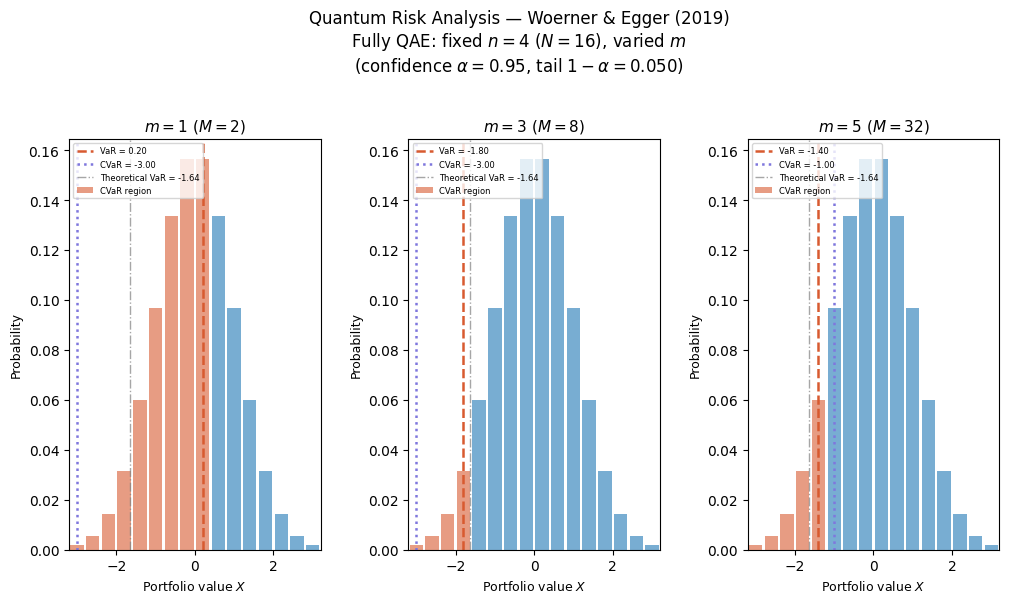

In [12]:
# ===================================================
# メイン実行
# ===================================================

alpha = 0.95     # 信頼水準。下側 tail probability は 1-alpha = 0.05
shots = 4096
mu = 0.0
sigma = 1.0
n = 4
m_list = [1, 3, 5]

tail_prob = 1.0 - alpha

print("=" * 60)
print("Quantum Risk Analysis — Fully QAE (Woerner--Egger u=0 F)")
print(f"n={n} fixed (N={2**n}), m={m_list}")
print(
    f"confidence alpha={alpha:.2f} ({alpha:.0%}), "
    f"lower-tail probability={tail_prob:.2f} ({tail_prob:.0%})"
)
print(f"mu={mu}, sigma={sigma}")
print("=" * 60)

z = norm.ppf(tail_prob)
theory_var = norm.ppf(tail_prob, mu, sigma)
theory_cvar = mu - sigma * norm.pdf(z) / tail_prob
print(
    f"\nContinuous normal: VaR_{alpha:.0%}={theory_var:.4f}, "
    f"CVaR_{alpha:.0%}={theory_cvar:.4f}\n"
)

amplitudes = make_normal_amplitudes(n, mu=mu, sigma=sigma)
results_by_m = {}

for m in m_list:
    print(f"\n{'=' * 45}")
    print(f"m={m} (M={2**m})")
    print(f"{'=' * 45}")

    var_idx, var_x, prob_var = compute_var(
        alpha,
        n,
        m,
        amplitudes,
        mu=mu,
        sigma=sigma,
        shots=shots,
    )

    cvar = compute_cvar(
        alpha,
        var_idx,
        var_x,
        prob_var,
        n,
        m,
        amplitudes,
        mu=mu,
        sigma=sigma,
        shots=shots,
    )

    print("\n--- result ---")
    print(
        f"VaR_{alpha:.0%}  = {var_x:.4f}  "
        f"(continuous normal {theory_var:.4f})"
    )
    print(
        f"CVaR_{alpha:.0%} = {cvar:.4f}  "
        f"(continuous normal {theory_cvar:.4f})"
    )

    results_by_m[m] = {
        "var_alpha_index": var_idx,
        "var_alpha_x": var_x,
        "prob_var": prob_var,
        "cvar_alpha": cvar,
    }

plot_results_vs_m(
    results_by_m,
    n=n,
    alpha=alpha,
    mu=mu,
    sigma=sigma,
)


入力として用いた離散正規分布、そして QAE により推定した VaR および CVaR を縦線で示しています。
オレンジ色の棒グラフは VaR 以下の下側テイル領域、青色部分は VaR を超える領域を表しています。
$m$ は QAE 内部の QPE で用いる位相推定レジスタの量子ビット数であり、$M=2^m$ によって位相、そして振幅推定の分解能が決まります。
この結果では、$m=1$ に比べて $m=3,5$ で VaR の推定値は大きく改善しています。
ただし有限な $m$ の QAE では推定可能な振幅が離散的であり、その値を用いて二分探索を行うため、$m$ の増加に対して VaR の誤差が必ず単調に減少するとは限りません。
一方、CVaR は VaR 以下の領域に対する条件付き期待値であり、この実装では $u=0$ でのテイラー展開近似による $F$ を利用しています。  
そのため、CVaR の誤差には QAE の有限精度だけでなく、$F$ の近似誤差や VaR 推定誤差も含まれます。
特にテイルの確率が小さい場合、条件付き期待値を復元する際に QAE の誤差が増幅されるため、今回の結果からは CVaR が $m$ とともに単調に改善していることは確認できません。
また、量子回路に入力している分布は $N=2^n$ 点に離散化された分布であるため、QAE の推定誤差とは別に $n$ に由来する離散化誤差も存在します。
したがって精度を高めるには、QAE の分解能を決める $m$ と、確率分布の離散化精度を決める $n$ の双方を考慮する必要があります。